<a href="https://colab.research.google.com/github/drawcodeboy/Cat_n_Dog_Classification/blob/main/cat_n_dog_modeling_ver2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.model_selection import train_test_split

In [50]:
# Modeling
model = keras.Sequential()
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', 
                              kernel_regularizer=tf.keras.regularizers.l2(0.02), 
                              padding = 'same', input_shape=(224, 224, 1)))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', 
                              kernel_regularizer=tf.keras.regularizers.l2(0.02), 
                              padding = 'same'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(1000, activation='relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(50, activation='relu'))
model.add(keras.layers.Dense(1, activation='sigmoid'))

In [51]:
hist = []

def fit_and_del(set_path, target_path):
    # Load data
    train_set_pt = np.load(set_path, allow_pickle=True)
    train_target_pt = np.load(target_path, allow_pickle=True)

    # Normalization
    train_set_pt_scaled = train_set_pt / 255.0
    
    del train_set_pt
    
    # train_set, validation_set 분리
    x_train, x_val, y_train, y_val = train_test_split(
        train_set_pt_scaled, train_target_pt, test_size=0.2, random_state=42
    )

    del train_set_pt_scaled
    del train_target_pt

    # Training
    hist_temp = model.fit(x_train, y_train, epochs=10, validation_data=(x_val, y_val),
               batch_size = 64)
    
    hist.append(hist_temp)

    del x_train
    del x_val
    del y_train
    del y_val

In [52]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics='accuracy')

early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

In [5]:
train_path = '/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled'
train_path_list = []

for dirname, _, filenames in os.walk(train_path):
    for filename in filenames:
        if(filename.endswith('npy')):
            train_set_part_path = os.path.join(dirname, filename)
            train_path_list.append(train_set_part_path)

train_path_list.sort()

In [6]:
train_target_path = '/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part'
train_target_path_list = []

for dirname, _, filenames in os.walk(train_target_path):
    for filename in filenames:
        if(filename.endswith('npy')):
            train_target_part_path = os.path.join(dirname, filename)
            train_target_path_list.append(train_target_part_path)
        
train_target_path_list.sort()

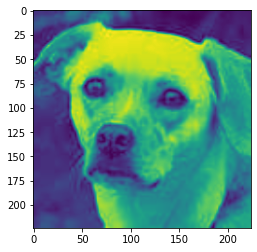

1


In [7]:
a = np.load(train_path_list[0], allow_pickle=True)
b = np.load(train_target_path_list[0], allow_pickle=True)

plt.imshow(a[6])
plt.show()
print(b[6])

In [8]:
for i in range(0, 4):
    a = np.load(train_path_list[i], allow_pickle=True)
    b = np.load(train_target_path_list[i], allow_pickle=True)

    print(len(a), len(b), sep=' ', end='\n')
    print(train_path_list[i], train_target_path_list[i])
    print(a.shape, b.shape)
    del a
    del b

2000 2000
/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_1.npy /content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_1.npy
(2000, 224, 224) (2000,)
2000 2000
/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_2.npy /content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_2.npy
(2000, 224, 224) (2000,)
2000 2000
/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_3.npy /content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_3.npy
(2000, 224, 224) (2000,)
2005 2005
/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_4.npy /content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_4.npy
(2005, 224, 224) (2005,)


In [53]:
for i, data in enumerate(zip(train_path_list, train_target_path_list), start=1):
    print('Part {} Training...'.format(i))
    fit_and_del(data[0], data[1])

Part 1 Training...
Epoch 1/10
25/25 [==============================] - 1s 39ms/step - loss: 1.8444 - accuracy: 0.4950 - val_loss: 1.2409 - val_accuracy: 0.4950
Epoch 2/10
25/25 [==============================] - 1s 28ms/step - loss: 1.1337 - accuracy: 0.5987 - val_loss: 1.0646 - val_accuracy: 0.5375
Epoch 3/10
25/25 [==============================] - 1s 28ms/step - loss: 0.9865 - accuracy: 0.6481 - val_loss: 0.9884 - val_accuracy: 0.5200
Epoch 4/10
25/25 [==============================] - 1s 29ms/step - loss: 0.8949 - accuracy: 0.6662 - val_loss: 0.9448 - val_accuracy: 0.5725
Epoch 5/10
25/25 [==============================] - 1s 29ms/step - loss: 0.7479 - accuracy: 0.7688 - val_loss: 0.8956 - val_accuracy: 0.6775
Epoch 6/10
25/25 [==============================] - 1s 28ms/step - loss: 0.5914 - accuracy: 0.8587 - val_loss: 0.9375 - val_accuracy: 0.6800
Epoch 7/10
25/25 [==============================] - 1s 28ms/step - loss: 0.4578 - accuracy: 0.9175 - val_loss: 1.0811 - val_accuracy: 0

In [54]:
def show_graph(history_):
    accuracy = history_.history['accuracy']
    val_accuracy = history_.history['val_accuracy']
    loss = history_.history['loss']
    val_loss = history_.history['val_loss']

    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(10, 2))

    plt.subplot(121)
    plt.ylim(0, 1.1)
    plt.subplots_adjust(top=2)
    plt.plot(epochs, accuracy, 'ro', label='Training accuracy')
    plt.plot(epochs, val_accuracy, 'r', label='Validation accuracy')
    plt.title('Trainging and validation accuracy and loss')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy and Loss')

    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
              fancybox=True, shadow=True, ncol=5)
#     plt.legend(bbox_to_anchor=(1, -0.1))

    plt.subplot(122)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
          fancybox=True, shadow=True, ncol=5)
#     plt.legend(bbox_to_anchor=(1, 0))

    plt.show()

reference
https://chealin93.tistory.com/69

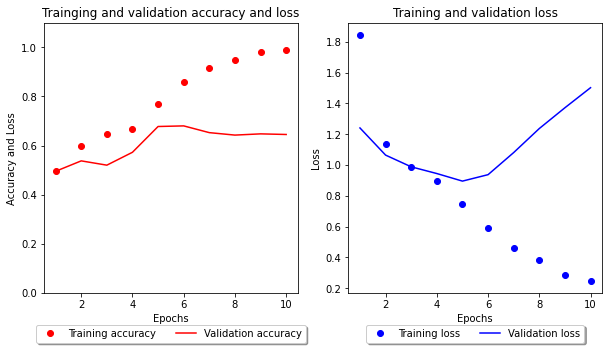

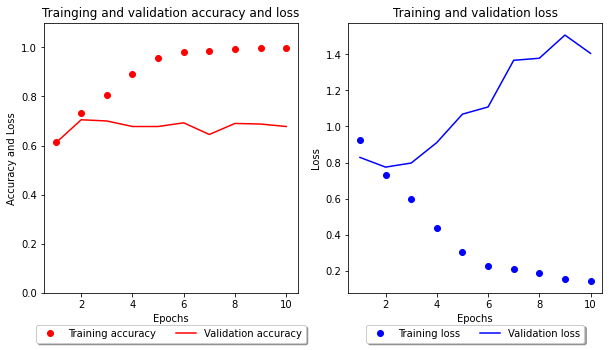

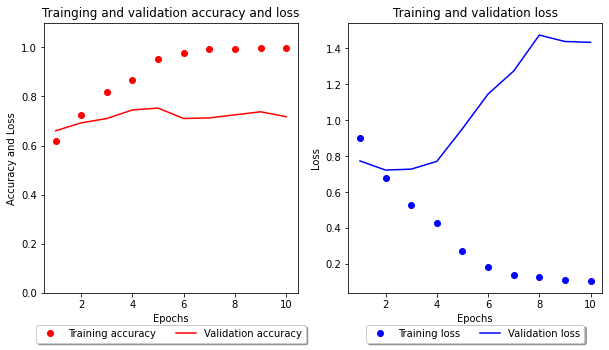

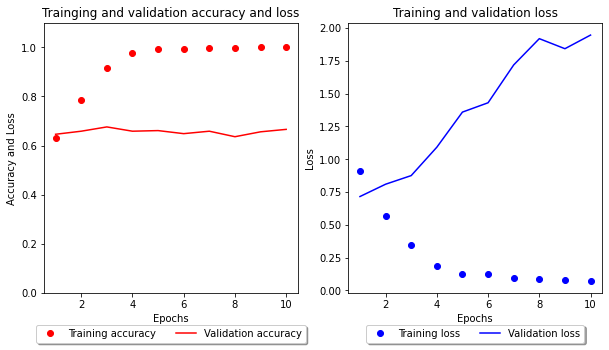

In [55]:
for x in hist:
    show_graph(x)

In [23]:
# Load Test Set

test_set = np.load('/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/test_set_scaled/test_scaled.npy', allow_pickle=True)
test_target = np.load('/content/drive/MyDrive/cat_n_dog/data_numpy/test_target.npy', allow_pickle=True)

In [56]:
test_set_scaled = test_set / 255.0

model.evaluate(test_set_scaled, test_target)

64/64 [==============================] - 0s 7ms/step - loss: 1.8984 - accuracy: 0.6565


[1.898376226425171, 0.6564508080482483]